In [67]:
import pandas as pd
import numpy as np


In [68]:
df = pd.read_csv('kidney_disease.csv')

In [69]:
df.shape

(400, 26)

In [70]:
df.info()  #there is null values in the dataset, we need to handle them before training the model.

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [71]:
df.head() #inputs datas are age, blood pressure, specific gravity, albumin, sugar, red blood cells, pus cell, pus cell clumps, bacteria, blood glucose random, blood urea, serum creatinine, sodium, potassium, hemoglobin, packed cell volume, white blood cell count, red blood cell count and hypertension.
          # The target variable is class which has two values: 'ckd' and 'notckd' 

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


Here we don't need id column. It is unnecessary data and not useful for our model, so we will drop it.

In [72]:
df.drop('id', axis = 1, inplace = True) #the id column is not useful for our model, so we will drop it.

In [73]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


Data handling.1

changing the columns names because they are not user friendly

In [74]:
#changing the columns names because they are not user friendly
df.columns = ['age', 'blood_pressure','specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 
              'pus_cell', 'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 
              'serum_creatinine', 'sodium', 'potassium', 'hemoglobin', 'packed_cell_volume', 
              'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'diabetes_mellitus',
              'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia','class']

In [75]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


Data handling.2

In the above datas, packed_cell_volume, white_blood_cell_count, red_blood_cell_count are in text datatype, we have to convert these into numeric type

In [76]:
text_columns = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
for i in text_columns:
    print(f"{i}: {df[i].dtype}")

packed_cell_volume: str
white_blood_cell_count: str
red_blood_cell_count: str


now convert the data type in to numaric (i.e., float)

In [77]:
def convert_text_to_numeric(df, column):
    df[column] = pd.to_numeric(df[column], errors='coerce')
    
for column in text_columns:
    convert_text_to_numeric(df, column)
    print(f"{column}: {df[column].dtype}")

packed_cell_volume: float64
white_blood_cell_count: float64
red_blood_cell_count: float64


Data handling.3

handling missing values

In [78]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False).head(20)


red_blood_cells           152
red_blood_cell_count      131
white_blood_cell_count    106
potassium                  88
sodium                     87
packed_cell_volume         71
pus_cell                   65
hemoglobin                 52
sugar                      49
specific_gravity           47
albumin                    46
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
blood_pressure             12
age                         9
pus_cell_clumps             4
bacteria                    4
hypertension                2
diabetes_mellitus           2
dtype: int64

In [79]:
df.columns  

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'class'],
      dtype='str')

data frames contain numeric as well as category columns

so we need to fill the column which contains numeric data with average and fill the column which contains category data with mode(frequent data)

In [80]:
# Separate columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Fill numeric columns with mean
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\mahes\AppData\Local\Temp\ipykernel_16484\1612962733.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [81]:
#now null values are handled
df.isnull().sum()

age                        0
blood_pressure             0
specific_gravity           0
albumin                    0
sugar                      0
red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
blood_glucose_random       0
blood_urea                 0
serum_creatinine           0
sodium                     0
potassium                  0
hemoglobin                 0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
pedal_edema                0
anemia                     0
class                      0
dtype: int64

Find unique values and replace

In [82]:
# Check unique values in categorical columns

print(f"diabetes_mellitus:- {df['diabetes_mellitus'].unique()}")
print(f"coronary_artery_disease:- {df['coronary_artery_disease'].unique()}")
print(f"class:- {df['class'].unique()} ")

diabetes_mellitus:- <StringArray>
['yes', 'no', ' yes', '\tno', '\tyes']
Length: 5, dtype: str
coronary_artery_disease:- <StringArray>
['no', 'yes', '\tno']
Length: 3, dtype: str
class:- <StringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str 


In [83]:
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({' yes': 'yes', '\tno': 'no', '\tyes': 'yes'})
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace({'\tno': 'no'})
df['class'] = df['class'].replace({'ckd\t': 'ckd', 'notckd': 'not ckd'})

In [84]:
#now again check unique values in categorical columns
print(f"diabetes_mellitus:- {df['diabetes_mellitus'].unique()}")
print(f"coronary_artery_disease:- {df['coronary_artery_disease'].unique()}")
print(f"class:- {df['class'].unique()} ")

diabetes_mellitus:- <StringArray>
['yes', 'no']
Length: 2, dtype: str
coronary_artery_disease:- <StringArray>
['no', 'yes']
Length: 2, dtype: str
class:- <StringArray>
['ckd', 'not ckd']
Length: 2, dtype: str 


FEATURE ENCODING

feature encoding - It means change the categorical values to numerical values because machine understand only numerical datas

By simple method is mapping because only their is 2types of catogory(i.e, yes, no and ckd, not ckd)

In [85]:
df['class'] = df['class'].map({'ckd': 1, 'not ckd': 0})
df['red_blood_cells'] = df['red_blood_cells'].map({'normal': 0, 'abnormal': 1})
df['pus_cell'] = df['pus_cell'].map({'normal': 0, 'abnormal': 1})
df['pus_cell_clumps'] = df['pus_cell_clumps'].map({'notpresent  ': 0, 'present': 1})
df['bacteria'] = df['bacteria'].map({'notpresent  ': 0, 'present': 1})
df['hypertension'] = df['hypertension'].map({'no': 0, 'yes': 1})
df['diabetes_mellitus'] = df['diabetes_mellitus'].map({'no': 0, 'yes': 1})
df['coronary_artery_disease'] = df['coronary_artery_disease'].map({'no': 0, 'yes': 1})
df['appetite'] = df['appetite'].map({'good': 1, 'poor': 0})
df['pedal_edema'] = df['pedal_edema'].map({'no': 0, 'yes': 1})
df['anemia'] = df['anemia'].map({'no': 0, 'yes': 1})


In [86]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,0,0,NaN,NaN,121.000000,...,44.0,7800.0,5.200000,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,0,0,NaN,NaN,148.036517,...,38.0,6000.0,4.707435,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,0,0,NaN,NaN,423.000000,...,31.0,7500.0,4.707435,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1.0,NaN,117.000000,...,32.0,6700.0,3.900000,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,NaN,NaN,106.000000,...,35.0,7300.0,4.600000,0,0,0,1,0,0,1


In [87]:
df.isnull().sum() #nan values are added

age                          0
blood_pressure               0
specific_gravity             0
albumin                      0
sugar                        0
red_blood_cells              0
pus_cell                     0
pus_cell_clumps            358
bacteria                   378
blood_glucose_random         0
blood_urea                   0
serum_creatinine             0
sodium                       0
potassium                    0
hemoglobin                   0
packed_cell_volume           0
white_blood_cell_count       0
red_blood_cell_count         0
hypertension                 0
diabetes_mellitus            0
coronary_artery_disease      0
appetite                     0
pedal_edema                  0
anemia                       0
class                        0
dtype: int64

In [88]:

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns


# Fill numeric columns with mean
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

CORELATION

It means how one column and other columns are related

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns   

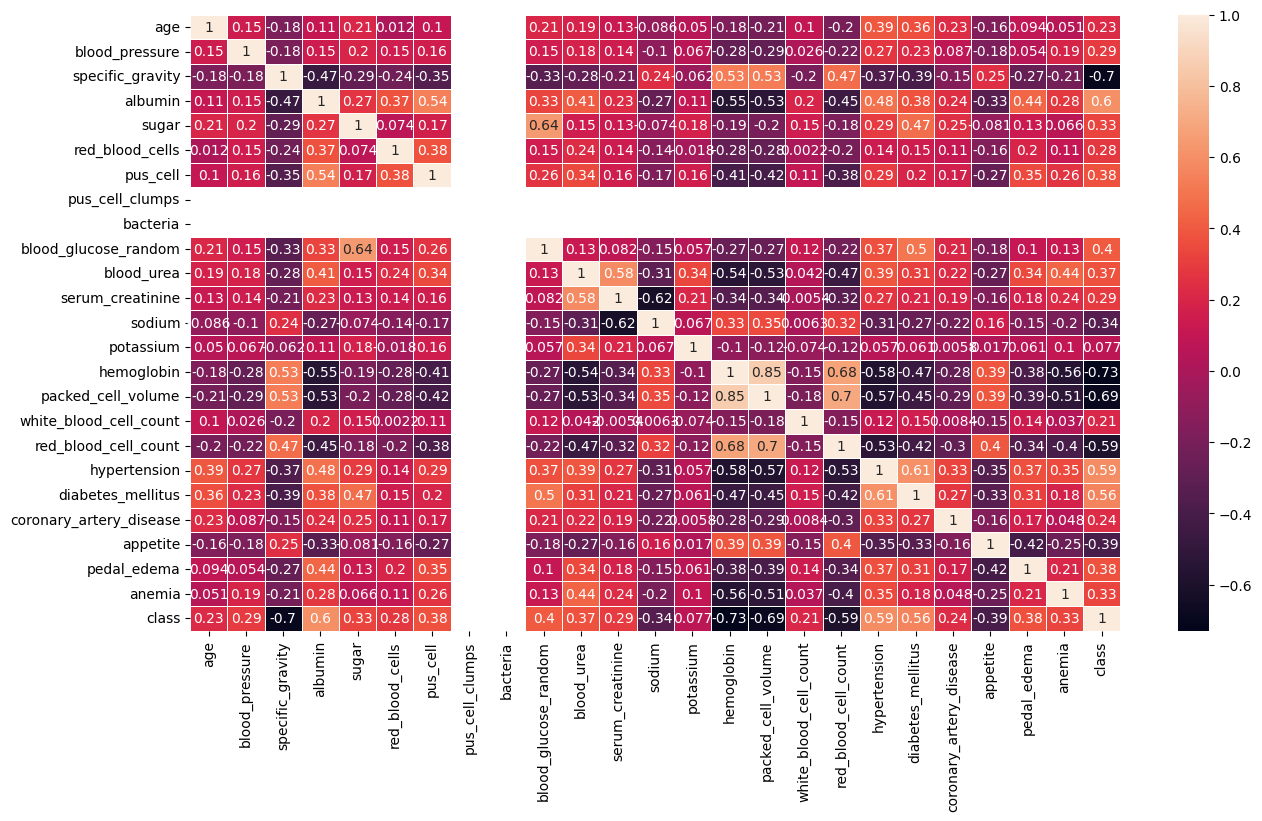

In [90]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, linewidths=0.5) #annot is annotaion
plt.show()

#correlation with target variable
#if correlation is greater than 1 then we can say that there is a perfect correlation between the feature and the target variable.
#if correlation is greater than 0.5 then we can say that there is a strong correlation between the feature and the target variable.
#if correlation is between 0.3 and 0.5 then we can say that there is a moderate correlation between the feature and the target variable.
#if correlation is less than 0.3 then we can say that there is a weak correlation between the feature and the target variable.
#if correlation is negative then we can say that there is a negative correlation between the feature and the target variable.
#if correlation is positive then we can say that there is a positive correlation between the feature and the target variable.


In [91]:
#i need only for feature class

target_correlation = df.corr()['class'].abs().sort_values(ascending=False)[1:] 
print(target_correlation)

#top greater than 0.5 are good coreltion

hemoglobin                 0.729628
specific_gravity           0.698957
packed_cell_volume         0.690060
albumin                    0.599238
red_blood_cell_count       0.590913
hypertension               0.590438
diabetes_mellitus          0.559060
blood_glucose_random       0.401374
appetite                   0.393341
pus_cell                   0.375154
pedal_edema                0.375154
blood_urea                 0.372033
sodium                     0.342288
sugar                      0.327812
anemia                     0.325396
serum_creatinine           0.294079
blood_pressure             0.290600
red_blood_cells            0.282642
coronary_artery_disease    0.236088
age                        0.225405
white_blood_cell_count     0.205274
potassium                  0.076921
pus_cell_clumps                 NaN
bacteria                        NaN
Name: class, dtype: float64


In [92]:
df['class'].value_counts() #there are 250 ckd and 150 not ckd patients in the dataset.

class
1    250
0    150
Name: count, dtype: int64

TRAIN TEST SPLIT

In [93]:
from sklearn.model_selection import train_test_split

X = df.drop("class", axis =1) #input datas, but without "class" column because "class" is a output
                              #hear axis = 1, because we need to drop column, if axis= 0 means the row will be droped 
y = df["class"]

#splitting the train and test
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=25) #test_size = 0.25, it means 25% testing and remaining training ,splitted randemly

print(f"'Xtrain shape: {X_train.shape}")
print(f"'Xtest shape: {X_test.shape}")

'Xtrain shape: (300, 24)
'Xtest shape: (100, 24)


In [94]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train, y_train)  #fit() understand the datas 
#when we run this default parameter shown

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [102]:
y_pdc = decision_tree.predict(X_test)
y_pdc #how we know if the prediction is right or wrong? If we want to know the prediction is right or wrong we need to use classification mertrics

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1])

In [96]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [97]:
models = []
models.append(('Naive Bayes', GaussianNB()))
models.append(('KNN', KNeighborsClassifier(n_neighbors= 8))) #firstofall, for KNN we have to decide howmany neighbors
models.append(('RandomForestClassifier', RandomForestClassifier()))
models.append(('DecisionTreeClassifier', DecisionTreeClassifier()))
models.append(('SVM',SVC(kernel='linear')))


In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [110]:
for name, model in models:
    print(name, model)
    print()  #empty line
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print('\n')
    
    print("accuraxy:", accuracy_score(y_test, y_pred))
    print('\n')
    
    print("precision score:", precision_score(y_test,y_pred))
    print('\n')
    
    print("recall score:", recall_score(y_test, y_pred))
    print('\n')
    
    print("f1 score", f1_score(y_test,y_pred))
    print('\n')

Naive Bayes GaussianNB()

confusion matrix:
 [[37  0]
 [ 5 58]]


accuraxy: 0.95


precision score: 1.0


recall score: 0.9206349206349206


f1 score 0.9586776859504132


KNN KNeighborsClassifier(n_neighbors=8)

confusion matrix:
 [[31  6]
 [18 45]]


accuraxy: 0.76


precision score: 0.8823529411764706


recall score: 0.7142857142857143


f1 score 0.7894736842105263


RandomForestClassifier RandomForestClassifier()

confusion matrix:
 [[35  2]
 [ 0 63]]


accuraxy: 0.98


precision score: 0.9692307692307692


recall score: 1.0


f1 score 0.984375


DecisionTreeClassifier DecisionTreeClassifier()

confusion matrix:
 [[35  2]
 [ 2 61]]


accuraxy: 0.96


precision score: 0.9682539682539683


recall score: 0.9682539682539683


f1 score 0.9682539682539683


SVM SVC(kernel='linear')

confusion matrix:
 [[34  3]
 [ 4 59]]


accuraxy: 0.93


precision score: 0.9516129032258065


recall score: 0.9365079365079365


f1 score 0.944




BEST in the abouve algorithm is Random forest because -n - - - accuracy = 0.98

KNN have less accuracy i.e., 0.76, so we can tune the model(tuning)


NEW DATA predicition

In [111]:
new_data = [[48,80,1.02,1,0,1,1,0,0,121,36,1.2,140,4.5,15.4,44,7800,5.2,1,1,0,1,0,0]]

prediction = model.predict(new_data)
print("Prediction:", prediction)

Prediction: [1]


c:\chronic kidney\cenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
